# Séance 3 — Nettoyage et qualité des données

**Durée pratique : 3 h 30** &nbsp;·&nbsp; Ateliers 3.1 à 3.4

## Ce que vous saurez faire à la fin

- classer les valeurs manquantes et choisir un traitement adapté à chaque colonne ;
- détecter les valeurs aberrantes par écart interquartile et par score z, et arbitrer ;
- normaliser des chaînes de caractères pour éliminer les faux doublons ;
- écrire une fonction de nettoyage idempotente qui journalise ce qu'elle modifie.

> **Le principe directeur de la séance.** Une décision de nettoyage n'est jamais neutre :
> elle change les résultats en aval. Chaque choix doit donc être **explicite, justifié et
> tracé**. Un pipeline qui supprime 4 % des lignes sans le dire est un pipeline dangereux.

> **Convention de nommage du module.** Le code est écrit en anglais et suit la PEP 8 :
> fonctions et variables en `snake_case`, constantes en `MAJUSCULES`. Les **noms de colonnes**
> restent en français parce qu'ils viennent de la source : renommer les colonnes d'un fichier
> d'entrée est une transformation comme une autre, elle se décide et se documente, elle ne se
> fait pas par réflexe. Vous rencontrerez cette situation partout en entreprise.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_DIR = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

print('Données disponibles :')
for path in sorted(RAW_DIR.glob('*')):
    print(' ', path.name)


# Parquet conserve les types (dates, entiers, catégories) là où le CSV les perd :
# c'est le format à privilégier entre deux étapes d'un pipeline. Repli automatique
# sur le CSV si pyarrow n'est pas installé.
def save_dataset(df, name):
    try:
        path = PROCESSED_DIR / f'{name}.parquet'
        df.to_parquet(path, index=False)
    except ImportError:
        path = PROCESSED_DIR / f'{name}.csv'
        df.to_csv(path, index=False)
        print('(pyarrow absent : repli sur le CSV)')
    print('écrit :', path.name, df.shape)
    return path


def load_dataset(name):
    parquet_path = PROCESSED_DIR / f'{name}.parquet'
    csv_path = PROCESSED_DIR / f'{name}.csv'
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    raise FileNotFoundError(f'{name} introuvable : exécutez le notebook précédent')


def dataset_exists(name):
    return ((PROCESSED_DIR / f'{name}.parquet').exists()
            or (PROCESSED_DIR / f'{name}.csv').exists())

Données disponibles :
  .gitkeep
  capteurs.csv
  clients.csv
  magasins.csv
  produits.csv
  ventes_brutes.csv
  ventes_extrait.json
  ventes_extrait.xlsx


In [2]:
def parse_price(series):
    """Convertit une colonne de prix mixte (nombre ou texte '123,45 EUR') en float."""
    text = series.astype(str).str.replace(' EUR', '', regex=False)
    return pd.to_numeric(text.str.replace(',', '.', regex=False).str.strip(),
                         errors='coerce')


sales = pd.read_csv(RAW_DIR / 'ventes_brutes.csv')
customers = pd.read_csv(RAW_DIR / 'clients.csv')
sales['prix_unitaire'] = parse_price(sales['prix_unitaire'])

print(sales.shape, customers.shape)

(17609, 11) (3060, 5)


---
## Atelier 3.1 — Cartographier les valeurs manquantes (60 min)

### Partie guidée

Avant de choisir un traitement, il faut savoir **pourquoi** la valeur est absente.
La typologie classique distingue trois cas :

| Type | Signification | Conséquence |
|---|---|---|
| MCAR | absence totalement aléatoire | supprimer ne biaise pas, on perd seulement de la puissance |
| MAR | absence expliquée par d'autres colonnes | imputation conditionnelle possible et souhaitable |
| MNAR | absence liée à la valeur elle-même | tout traitement biaise ; l'absence doit devenir une information |

On ne peut pas prouver le type à partir des seules données. On l'argumente à partir de la
connaissance du processus qui les a produites.

In [3]:
missing_summary = pd.DataFrame({
    'nb_manquants': sales.isna().sum(),
    'taux_pct': (sales.isna().mean() * 100).round(2),
})
missing_summary[missing_summary['nb_manquants'] > 0].sort_values('taux_pct', ascending=False)

,nb_manquants,taux_pct
remise_pct,1941,11.02
date_commande,350,1.99


In [4]:
# Les remises manquantes le sont-elles au hasard ? Comparons les lignes concernées
# au reste du jeu sur quelques variables.
has_no_discount = sales['remise_pct'].isna()

comparison = pd.DataFrame({
    'remise manquante': sales[has_no_discount][['quantite', 'prix_unitaire']].mean(),
    'remise renseignée': sales[~has_no_discount][['quantite', 'prix_unitaire']].mean(),
}).round(2)
print(comparison)
print()
print('Répartition des statuts, remise manquante :')
print(sales[has_no_discount]['statut'].value_counts(normalize=True).round(3))
print('Répartition des statuts, remise renseignée :')
print(sales[~has_no_discount]['statut'].value_counts(normalize=True).round(3))

               remise manquante  remise renseignée
quantite                   4.71               4.34
prix_unitaire            614.74             617.21

Répartition des statuts, remise manquante :
statut
livre       0.676
annule      0.173
retourne    0.150
Name: proportion, dtype: float64
Répartition des statuts, remise renseignée :
statut
livre       0.669
annule      0.168
retourne    0.164
Name: proportion, dtype: float64


**Lecture.** Si les deux profils sont semblables, l'hypothèse MCAR est plausible et une
imputation simple par zéro se défend (pas de remise saisie = pas de remise accordée).
S'ils diffèrent nettement, l'absence porte de l'information : créer un indicateur
`remise_absente` devient préférable à une imputation silencieuse.

### Partie autonome

In [5]:
# Q1. Même analyse pour la colonne 'age' de customers : les âges manquants se
#     concentrent-ils sur certains segments ou certaines villes ?

# La ville est normalisée d'abord, sinon 'Lyon', 'LYON' et '  Lyon ' seraient trois groupes.
city = customers['ville'].str.strip().str.title()
has_no_age = customers['age'].isna()

print('Taux global d\'âges manquants :', f'{has_no_age.mean():.1%}')
print()
print('Taux d\'âges manquants par segment :')
print(has_no_age.groupby(customers['segment']).mean().mul(100).round(1).to_string())
print()
print('Taux d\'âges manquants par ville :')
print(has_no_age.groupby(city).mean().mul(100).round(1).sort_values().to_string())

# Avant de conclure : des âges renseignés mais impossibles, qui sont en réalité
# des absences déguisées (codes de remplissage).
impossible_age = (customers['age'] < 0) | (customers['age'] > 120)
print()
print('Âges impossibles :', impossible_age.sum())
print(customers.loc[impossible_age, 'age'].value_counts().to_string())

Taux global d'âges manquants : 6.0%

Taux d'âges manquants par segment :
segment
Association      6.5
Particulier      5.7
Professionnel    6.3

Taux d'âges manquants par ville :
ville
Toulouse      4.7
Paris         4.8
Strasbourg    5.5
Lyon          5.8
Lille         6.0
Nantes        6.5
Marseille     7.5
Bordeaux      7.5

Âges impossibles : 33
age
 999.0    20
-1.0      12
-16.0      1


**Pourquoi cette réponse (Q1).**
On compare le **taux** d'âges manquants par groupe (moyenne d'un masque booléen), pas le nombre : un segment
plus grand aurait mécaniquement plus d'absences. La ville est normalisée d'abord, sinon chaque variante
d'écriture formerait un faux groupe.

**Lecture.** Les taux sont proches partout, autour de 6 % (de 5,7 à 6,5 % selon le segment, de 4,7 à 7,5 % selon
la ville). Aucun groupe ne concentre les absences : l'hypothèse **MCAR** est plausible.

**Mais le vrai problème est ailleurs** : 33 âges sont renseignés et impossibles (20 × `999`, 12 × `-1`, 1 × `-16`).
`999` et `-1` sont des **codes de remplissage** : des absences déguisées en nombres. Ils doivent être convertis en `NaN`
**avant** toute imputation, sinon ils faussent la moyenne (46,5 ans au lieu d'environ 40) et l'écart type.

In [6]:
# Q2. Rédiger une stratégie colonne par colonne, sous forme de dictionnaire.
#     Valeurs autorisées : 'drop_row', 'fill_zero', 'fill_median',
#     'fill_median_by_group', 'add_indicator', 'keep_as_is'.
#     La justification est OBLIGATOIRE : c'est elle qui sera évaluée, pas le choix lui-même.

missing_value_strategy = {
    'date_commande': ('drop_row',
                      'une commande sans date est inexploitable pour toute analyse temporelle'),
    'remise_pct':    ('fill_zero',
                      'profils quantité/prix/statut identiques avec ou sans remise (MCAR plausible) : '
                      'pas de remise saisie = pas de remise accordée'),
    'age':           ('fill_median',
                      'après conversion des codes 999 et -1 en NaN, absences réparties uniformément '
                      'entre segments et villes (MCAR) : la médiane, robuste, suffit'),
    'cout_achat':    ('fill_median_by_group',
                      'un seul produit concerné (P0023, Bureau modèle 2) : la médiane de sa sous-catégorie '
                      'est plus proche de son vrai coût que la médiane de tous les produits'),
}

for column, (action, rationale) in missing_value_strategy.items():
    print(f'{column:<16} {action:<24} {rationale}')

date_commande    drop_row                 une commande sans date est inexploitable pour toute analyse temporelle
remise_pct       fill_zero                profils quantité/prix/statut identiques avec ou sans remise (MCAR plausible) : pas de remise saisie = pas de remise accordée
age              fill_median              après conversion des codes 999 et -1 en NaN, absences réparties uniformément entre segments et villes (MCAR) : la médiane, robuste, suffit
cout_achat       fill_median_by_group     un seul produit concerné (P0023, Bureau modèle 2) : la médiane de sa sous-catégorie est plus proche de son vrai coût que la médiane de tous les produits


**Pourquoi ces choix (Q2).**
- `date_commande` → `drop_row` : on ne peut pas inventer une date sans fausser les analyses temporelles, et
  cela ne concerne que 2 % des lignes.
- `remise_pct` → `fill_zero` : l'atelier guidé montre des profils identiques avec ou sans remise. Côté métier,
  un champ vide signifie le plus souvent « pas de remise ». **Limite à connaître** : si l'absence était en réalité
  un oubli de saisie, remplacer par 0 sous-estimerait la remise moyenne.
- `age` → `fill_median` : les absences sont réparties uniformément (Q1). La **médiane plutôt que la moyenne**
  parce qu'elle n'est pas tirée par les valeurs extrêmes, comme les codes 999 s'il en restait. Un remplissage par
  groupe n'apporterait rien, puisqu'aucun groupe ne se distingue.
- `cout_achat` → `fill_median_by_group` : un seul produit, un bureau. La médiane des autres bureaux (modèles 1 et 3)
  est bien plus réaliste que celle de tous les produits, qui mélange câbles et ordinateurs.

---
## Atelier 3.2 — Valeurs aberrantes : deux méthodes, deux verdicts (55 min)

### Partie guidée

In [7]:
def iqr_bounds(series, factor=1.5):
    """Bornes de Tukey : robustes, car fondées sur des quantiles."""
    q1, q3 = series.quantile([0.25, 0.75])
    spread = q3 - q1
    return q1 - factor * spread, q3 + factor * spread


def zscore_bounds(series, n_std=3):
    """Bornes par score z : sensibles, car moyenne et écart type sont eux-mêmes
    tirés vers le haut par les valeurs extrêmes."""
    mean, std = series.mean(), series.std()
    return mean - n_std * std, mean + n_std * std


quantity = sales['quantite']
for label, (lower, upper) in [('IQR    ', iqr_bounds(quantity)),
                              ('score z', zscore_bounds(quantity))]:
    n_flagged = ((quantity < lower) | (quantity > upper)).sum()
    print(f'{label} bornes [{lower:8.2f} ; {upper:8.2f}]  ->  {n_flagged:>4} valeurs signalées')

IQR     bornes [   -2.00 ;     6.00]  ->    74 valeurs signalées
score z bornes [ -119.00 ;   127.75]  ->    61 valeurs signalées


Les deux méthodes ne s'accordent pas, et l'écart est instructif. Le score z est calculé à
partir de la moyenne et de l'écart type, deux statistiques que les valeurs extrêmes
**déforment elles-mêmes**. Quelques quantités à 1 000 suffisent à gonfler l'écart type au
point que ces mêmes valeurs passent sous le seuil de détection. L'IQR, fondé sur des
quantiles, ne souffre pas de cet effet.

In [8]:
# Regarder les valeurs concernées avant de décider quoi que ce soit
print('Quantités les plus élevées :')
print(sales.nlargest(8, 'quantite')[['id_commande', 'quantite', 'prix_unitaire', 'statut']])
print()
print('Quantités négatives :', (sales['quantite'] < 0).sum())
print(sales[sales['quantite'] < 0][['id_commande', 'quantite', 'statut']].head())

Quantités les plus élevées :
      id_commande  quantite  prix_unitaire    statut
3498   CMD0000204      1199         542.83     livre
4204   CMD0000063      1163         949.23     livre
360    CMD0004120      1128         413.11     livre
10360  CMD0016201      1098         982.04  retourne
15880  CMD0003400      1092          66.77     livre
6745   CMD0002168      1081          90.34  retourne
12339  CMD0002491      1053         903.19  retourne
12341  CMD0006289      1002         614.04     livre

Quantités négatives : 30
     id_commande  quantite    statut
46    CMD0006153        -3     livre
757   CMD0017746        -4  retourne
1409  CMD0014959        -1     livre
1473  CMD0005010        -4    annule
1896  CMD0003955        -4     livre


**Deux problèmes de nature différente sont ici confondus.** Les quantités négatives sont
*impossibles* : c'est une erreur de saisie ou de signe, elle se corrige ou se supprime sans
état d'âme. Les quantités à 800 sont *improbables* mais pas impossibles : il peut s'agir de
commandes professionnelles légitimes. Les traiter de la même façon serait une faute
méthodologique.

### Partie autonome

In [9]:
# Q3. Écrire une fonction qui, pour une colonne donnée, renvoie un DataFrame comparant
#     les deux méthodes : nb détectés, part en %, valeur min et max des points signalés.

def compare_outlier_methods(df, column):
    series = df[column].dropna()
    rows = {}
    for label, (lower, upper) in [('IQR', iqr_bounds(series)),
                                  ('score z', zscore_bounds(series))]:
        flagged = series[(series < lower) | (series > upper)]
        rows[label] = {
            'borne_basse': round(lower, 2),
            'borne_haute': round(upper, 2),
            'nb_detectes': len(flagged),
            'part_%': round(len(flagged) / len(series) * 100, 2),
            'min_signale': flagged.min() if len(flagged) else None,
            'max_signale': flagged.max() if len(flagged) else None,
        }
    return pd.DataFrame(rows).T


display(compare_outlier_methods(sales, 'quantite'))
display(compare_outlier_methods(sales, 'prix_unitaire'))

,borne_basse,borne_haute,nb_detectes,part_%,min_signale,max_signale
IQR,-2.0,6.00,74.0,0.42,-4.0,1199.0
score z,-119.0,127.75,61.0,0.35,303.0,1199.0


,borne_basse,borne_haute,nb_detectes,part_%,min_signale,max_signale
IQR,-693.53,1898.98,0.0,0.0,NaN,NaN
score z,-417.32,1651.20,0.0,0.0,NaN,NaN


**Pourquoi cette réponse (Q3).**
La fonction réutilise `iqr_bounds` et `zscore_bounds` au lieu de recopier les formules. Pour chaque méthode, elle
repère les points hors bornes et résume ce qu'elle a trouvé dans une ligne du tableau. `dropna()` évite que des
valeurs manquantes faussent les quantiles.

**Lecture.** Sur `quantite`, l'IQR signale plus de points que le score z. Les quelques valeurs à 1 000 gonflent
tellement l'écart type (41 pour une médiane de 2) que la borne z monte au-delà de 100 : les valeurs modérément
hautes passent sous le radar. C'est l'effet de masquage décrit dans l'atelier. Sur `prix_unitaire`, la
distribution est régulière et sans queue : **aucune** méthode ne signale rien. Il n'y a pas d'aberrant à traiter.

Quantités <= 0 exclues du graphique : 30


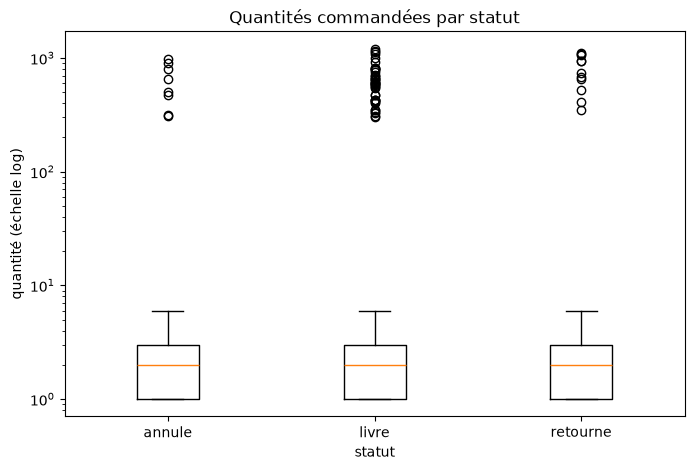

In [10]:
# Q4. Visualiser. Un boxplot par statut pour la quantité, en échelle logarithmique
#     sur l'axe des ordonnées (sans quoi les valeurs extrêmes écrasent tout le reste).

import matplotlib.pyplot as plt

# log(x) n'existe pas pour x <= 0 : les quantités négatives sont exclues du graphique,
# et on le dit, plutôt que de les laisser disparaître en silence.
positive = sales[sales['quantite'] > 0]
print('Quantités <= 0 exclues du graphique :', len(sales) - len(positive))

statuses = sorted(positive['statut'].unique())
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([positive.loc[positive['statut'] == s, 'quantite'] for s in statuses])
ax.set_xticks(range(1, len(statuses) + 1), statuses)
ax.set_yscale('log')
ax.set_xlabel('statut')
ax.set_ylabel('quantité (échelle log)')
ax.set_title('Quantités commandées par statut')
plt.show()

**Pourquoi cette réponse (Q4).**
L'échelle logarithmique affiche 1, 10, 100 et 1 000 à égale distance. Sans elle, la boîte des quantités normales
(1 à 3) serait écrasée en une ligne au pied du graphique. Or le logarithme n'est défini que pour des valeurs
strictement positives : les 30 quantités négatives sont exclues, **et on l'affiche**. Une exclusion silencieuse
est exactement ce que la séance apprend à éviter.

**Lecture.** Les trois statuts ont la même distribution et les mêmes points extrêmes. Les grosses quantités ne
sont donc pas liées au statut, par exemple à des retours.

In [11]:
# Q5. Appliquer un traitement différencié et JOURNALISER ce qui est fait :
#       - quantités négatives : à décider et justifier ;
#       - quantités au-delà de la borne haute IQR : à décider et justifier.
#     La fonction renvoie (df_traité, log) où log est un dict des comptes.

def handle_quantity_outliers(df):
    df = df.copy()
    log = {'lignes_initiales': len(df)}

    # Négatives : IMPOSSIBLES. Elles touchent les trois statuts (pas seulement 'retourne'),
    # on ne peut donc pas les lire comme des retours. Elles ne représentent que 0,2 % des
    # lignes : on les supprime.
    is_negative = df['quantite'] < 0
    log['negatives_supprimees'] = int(is_negative.sum())
    df = df[~is_negative]

    # Au-delà de la borne haute IQR : IMPROBABLES, pas impossibles. On ne détruit pas
    # l'information : les lignes sont conservées et signalées par un indicateur.
    # L'analyse en aval choisira de les inclure ou non, en connaissance de cause.
    upper = iqr_bounds(df['quantite'])[1]
    df['quantite_suspecte'] = df['quantite'] > upper
    log['borne_haute_iqr'] = float(upper)
    log['suspectes_signalees'] = int(df['quantite_suspecte'].sum())

    log['lignes_finales'] = len(df)
    return df, log


sales_fixed, quantity_log = handle_quantity_outliers(sales)
print(quantity_log)

# Pourquoi on ne peut pas ignorer ces lignes : leur poids dans le chiffre d'affaires
revenue = sales_fixed['quantite'] * sales_fixed['prix_unitaire']
share = revenue[sales_fixed['quantite_suspecte']].sum() / revenue.sum()
print(f"Part du chiffre d'affaires portée par les quantités suspectes : {share:.1%}")

# Et elles ne ressemblent pas à des commandes professionnelles
segment = sales_fixed['id_client'].map(customers.set_index('id_client')['segment'])
print(pd.DataFrame({
    'toutes les ventes': segment.value_counts(normalize=True),
    'quantités suspectes': segment[sales_fixed['quantite_suspecte']].value_counts(normalize=True),
}).mul(100).round(1))

{'lignes_initiales': 17609, 'negatives_supprimees': 30, 'borne_haute_iqr': 6.0, 'suspectes_signalees': 61, 'lignes_finales': 17579}
Part du chiffre d'affaires portée par les quantités suspectes : 52.0%
               toutes les ventes  quantités suspectes
id_client                                            
Particulier                 50.5                 59.0
Professionnel               31.9                 26.2
Association                 17.6                 14.8


**Pourquoi ces décisions (Q5).**
- **Négatives → supprimées.** Une quantité négative est *impossible*. On aurait pu la lire comme un retour et
  prendre sa valeur absolue, mais elles apparaissent aussi sur des commandes *livrées* et *annulées* : rien ne
  permet de deviner la bonne valeur. 30 lignes, soit 0,2 % du jeu : les supprimer ne biaise rien.
- **Au-delà de la borne IQR → conservées et signalées** (colonne `quantite_suspecte`). Elles sont *improbables*,
  pas impossibles : les supprimer serait une perte d'information irréversible. Mais on ne peut pas les ignorer :
  **ces 61 lignes (0,3 % des ventes) portent 52 % du chiffre d'affaires**. Et elles ne viennent pas surtout de clients
  professionnels, ce qui aurait justifié de gros volumes. Ce sont donc très probablement des erreurs de saisie,
  que l'analyse en aval devra exclure ou traiter à part, grâce à l'indicateur.
- Le `log` enregistre chaque compte : on peut dire exactement ce qui a été fait, et le justifier.

---
## Atelier 3.3 — Doublons et incohérences textuelles (45 min)

### Partie guidée

In [12]:
print('Doublons stricts (toutes colonnes identiques) :', sales.duplicated().sum())
print('Doublons sur id_commande seul                 :', sales.duplicated('id_commande').sum())

Doublons stricts (toutes colonnes identiques) : 240
Doublons sur id_commande seul                 : 240


Les deux comptes diffèrent : certaines lignes partagent un identifiant de commande sans
être identiques. Avant de supprimer, il faut regarder ce qui les distingue.

In [13]:
repeated_ids = sales[sales.duplicated('id_commande', keep=False)]['id_commande'].unique()[:2]
sales[sales['id_commande'].isin(repeated_ids)].sort_values('id_commande')

,id_commande,date_commande,id_client,id_produit,id_magasin,quantite,prix_unitaire,remise_pct,canal,statut,ville_livraison
13,CMD0000105,2023/07/29 19:47,C01517,P0014,M99,2,1053.99,NaN,web,livre,Lyon
13443,CMD0000105,2023/07/29 19:47,C01517,P0014,M99,2,1053.99,NaN,web,livre,Lyon
18,CMD0000173,24-05-2023,C02747,P0002,M02,2,538.60,15.0,BOUTIQUE,annule,Marseille
2557,CMD0000173,24-05-2023,C02747,P0002,M02,2,538.60,15.0,BOUTIQUE,annule,Marseille


In [14]:
# Faux doublons textuels : la même ville écrite de plusieurs façons
print(sales['ville_livraison'].value_counts().head(12))

ville_livraison
Toulouse      1560
Lyon          1523
Paris         1521
Bordeaux      1510
Lille         1475
Marseille     1473
Nantes        1471
Strasbourg    1379
STRASBOURG     295
lyon           278
LYON           275
paris          275
Name: count, dtype: int64


In [15]:
def normalize_text(series):
    """Casse, espaces et accents : trois sources de faux niveaux."""
    text = series.astype(str).str.strip().str.lower()
    text = text.str.normalize('NFKD').str.encode('ascii', 'ignore').str.decode('utf-8')
    return text.str.replace(r'\s+', ' ', regex=True)


print('Modalités avant normalisation :', sales['ville_livraison'].nunique())
print('Modalités après normalisation :', normalize_text(sales['ville_livraison']).nunique())

Modalités avant normalisation : 33
Modalités après normalisation : 9


### Le piège : ne jamais normaliser les colonnes identifiantes

La tentation est grande d'écrire `for column in df.select_dtypes('object'): df[column] = normalize_text(df[column])`
et d'en finir. **C'est une erreur qui casse silencieusement tout le pipeline.** Les colonnes
`id_client`, `id_produit`, `id_magasin` sont du texte pour pandas, mais ce sont des **clés**.
Les passer en minuscules transforme `P0027` en `p0027`, et la jointure de la séance 6 ne
trouvera plus aucune correspondance : vous obtiendrez un jeu entièrement vide, sans la
moindre erreur levée.

Déclarez donc explicitement les colonnes à normaliser, plutôt que de les déduire du type.

In [16]:
TEXT_COLUMNS = ['canal', 'statut', 'ville_livraison']          # descriptives uniquement
KEY_COLUMNS = ['id_commande', 'id_client', 'id_produit', 'id_magasin']  # à préserver

trial = sales.copy()
for column in TEXT_COLUMNS:
    trial[column] = normalize_text(trial[column])

print('Clés intactes            :', trial['id_produit'].dropna().str.isupper().all())
print('Descriptives normalisées :', trial['canal'].nunique(), 'modalités')

Clés intactes            : True
Descriptives normalisées : 3 modalités


### Partie autonome

In [17]:
# Q6. Normaliser toutes les colonnes de TEXT_COLUMNS, puis recompter les doublons stricts.
#     Le compte augmente-t-il ? Expliquez pourquoi dans un commentaire.

normalized = sales.copy()
for column in TEXT_COLUMNS:
    normalized[column] = normalize_text(normalized[column])

print('Doublons stricts avant normalisation :', sales.duplicated().sum())
print('Doublons stricts après normalisation :', normalized.duplicated().sum())
print('Doublons sur id_commande seul        :', normalized.duplicated('id_commande').sum())

# Le compte N'AUGMENTE PAS ici (240 -> 240). La normalisation ne peut que faire augmenter
# le compte : elle fusionne des valeurs, elle n'en sépare jamais. Il augmente quand une même
# commande a été ressaisie avec une casse ou des espaces différents ('Lyon' / 'LYON').
# Dans ce jeu, les 240 doublons sont des copies exactes (même casse, mêmes espaces), et
# aucune paire de commandes distinctes ne diffère UNIQUEMENT par la casse. Le contrôle
# reste indispensable : c'est pour cela qu'on normalise AVANT de dédoublonner.

Doublons stricts avant normalisation : 240
Doublons stricts après normalisation : 240


Doublons sur id_commande seul        : 240


**Pourquoi cette réponse (Q6).**
La normalisation fait passer `canal` de 9 à 3 modalités et `ville_livraison` de 33 à 9. Pourtant, le nombre de
doublons stricts reste à 240. Normaliser ne peut que **fusionner** des valeurs : le compte peut seulement augmenter
ou rester stable. Il augmente quand une même commande a été saisie deux fois avec une écriture différente. Ici,
les 240 doublons sont des copies exactes, et chaque id_commande en double correspond à une copie exacte (240 = 240).

**Remarque** : le texte de l'atelier guidé annonce que « les deux comptes diffèrent ». Ce n'est pas le cas avec ce
jeu de données. La démarche reste la bonne : on vérifie toujours, et on normalise **avant** de dédoublonner.

In [18]:
# Q7. Dans customers, identifier les doublons MÉTIER : même ville, même segment,
#     même date d'inscription et même âge, mais identifiant différent.
#     Combien de couples trouvez-vous ? Que proposez-vous d'en faire ?

BUSINESS_KEY = ['ville', 'segment', 'date_inscription', 'age']

customers_norm = customers.copy()
customers_norm['ville'] = normalize_text(customers_norm['ville'])

in_pair = customers_norm.duplicated(BUSINESS_KEY, keep=False)
pairs = customers_norm[in_pair].sort_values(BUSINESS_KEY)
print('Couples de doublons métier :', customers_norm.duplicated(BUSINESS_KEY).sum())
print('dont couples sans âge      :', pairs['age'].isna().sum() // 2)
print()
print(pairs.head(6).to_string())

# Qui sont les doublons ? Un format d'identifiant se distingue.
print()
print('Identifiants hors format C00000 dans les couples :',
      (~pairs['id_client'].str.match(r'^C\d{5}$')).sum())

# Proposition : ne pas supprimer, mais FUSIONNER. On construit une table de correspondance
# identifiant doublon -> identifiant canonique, qu'on appliquera aux ventes.
# La jointure se fait sur la clé métier : chaque doublon retrouve SON jumeau canonique.
is_canonical = pairs['id_client'].str.match(r'^C\d{5}$')
twins = pairs[~is_canonical].merge(pairs[is_canonical], on=BUSINESS_KEY,
                                   suffixes=('_doublon', '_canonique'))
id_mapping = dict(zip(twins['id_client_doublon'], twins['id_client_canonique']))

print('Correspondances créées :', len(id_mapping), '| exemple :', next(iter(id_mapping.items())))
print('Ventes rattachées à un identifiant doublon :', sales['id_client'].isin(id_mapping).sum())

Couples de doublons métier : 60
dont couples sans âge      : 5

     id_client date_inscription      segment     ville   age
63      C00064       2019-11-28  Particulier  bordeaux  23.0
3041    990041       2019-11-28  Particulier  bordeaux  23.0
1001    C01002       2022-05-30  Particulier  bordeaux  41.0
3059    990059       2022-05-30  Particulier  bordeaux  41.0
1241    C01242       2024-01-13  Particulier  bordeaux  44.0
3029    990029       2024-01-13  Particulier  bordeaux  44.0



Identifiants hors format C00000 dans les couples : 60


Correspondances créées : 60 | exemple : ('990041', 'C00064')
Ventes rattachées à un identifiant doublon : 347


**Pourquoi cette réponse (Q7).**
Un **doublon métier** est la même entité réelle sous deux identifiants : `duplicated()` sur toutes les colonnes ne
le voit pas, puisque l'identifiant diffère. On compare donc sur une **clé métier** (ville, segment, date, âge), après
normalisation de la ville.

**Résultat : 60 couples**, et dans chaque couple l'un des identifiants est au format `990xxx` au lieu de `C00000`.
Ce ne sont pas des coïncidences : un deuxième système a ressaisi ces clients. **Prudence** : 5 couples n'ont pas
d'âge, et `duplicated` considère deux `NaN` comme égaux. Pour ceux-là, la preuve repose sur 3 critères au lieu
de 4 : à vérifier avant de fusionner.

**Proposition : fusionner, ne pas supprimer.** Supprimer les fiches `990xxx` rendrait orphelines les 347 ventes qui
y sont rattachées : elles disparaîtraient d'une jointure en séance 6. On garde donc la fiche canonique `C00000`,
on remappe les ventes avec `id_mapping` (`sales['id_client'].replace(id_mapping)`), puis on supprime les fiches en
double. Chaque client retrouve ainsi tout son historique d'achats.

---
## Atelier 3.4 — Un module de nettoyage idempotent (50 min)

**Idempotent** signifie que réappliquer la fonction à son propre résultat ne change plus rien.
C'est une propriété essentielle : un pipeline relancé deux fois par erreur ne doit pas
produire un jeu de données différent.

In [19]:
# La fonction vit dans src/cleaning.py (livrable de la séance) : le notebook l'importe.
# Ouvrez le fichier pour lire le code commenté étape par étape.
import sys
sys.path.insert(0, str(ROOT / 'src'))

from cleaning import clean_sales

clean_sales_df, cleaning_log = clean_sales(pd.read_csv(RAW_DIR / 'ventes_brutes.csv'))

  lignes_initiales                         17609
  prix_non_convertibles                    0
  modalites_canal                          9 -> 3
  modalites_statut                         3 -> 3
  modalites_ville_livraison                33 -> 9
  doublons_supprimes                       240
  lignes_sans_date_supprimees              347
  remises_imputees_a_zero                  1874
  quantites_negatives_supprimees           30
  quantites_suspectes_signalees            59
  lignes_finales                           16992


**Pourquoi cette construction (atelier 3.4).**
Le code est dans `src/cleaning.py` : une seule version, importable dans les séances suivantes et dans le projet.
Les choix qui comptent :
- **L'ordre des étapes.** On normalise le texte *avant* de dédoublonner, sinon `'web'` et `'WEB'` masqueraient
  un doublon. On convertit les dates *avant* de supprimer les lignes sans date.
- **Des dates sans ambiguïté.** On essaie les cinq formats connus, un par un. Pas de devinette automatique, qui
  pourrait confondre le 08/01 et le 01/08 ; une date qui ne respecte aucun format devient `NaT`.
- **Idempotence.** Chaque conversion vérifie d'abord si elle a déjà été faite : les prix déjà numériques et les
  dates déjà converties ne sont pas retraités. La normalisation et `fillna(0)` ne changent rien quand on les
  réapplique. La borne IQR repose sur des quartiles, stables d'un passage à l'autre.
- **Le montant est net de remise**, `quantité × prix × (1 − remise/100)` : c'est le montant réellement encaissé.
- **Le journal** compte chaque ligne supprimée et chaque valeur imputée : `lignes_initiales − lignes_finales` s'explique
  entièrement par les étapes du journal.

In [20]:
# Q8. Vérifier l'idempotence : un second passage ne doit rien changer.

second_pass, _ = clean_sales(clean_sales_df, verbose=False)

assert len(second_pass) == len(clean_sales_df), "la fonction n'est pas idempotente"
assert second_pass.equals(clean_sales_df), 'le second passage modifie encore des valeurs'
print('OK — fonction idempotente')

OK — fonction idempotente


**Pourquoi ce test (Q8).**
On relance `clean_sales` sur son propre résultat. Deux conditions : le même nombre de lignes, **et** des valeurs
strictement identiques (`equals` compare aussi les types et l'index). Si une étape n'était pas idempotente, par
exemple une remise recalculée ou un prix reconverti, le second passage le révélerait. C'est la garantie qu'un
pipeline relancé par erreur ne corrompt pas les données.

In [21]:
# Export du résultat et du journal, pour la séance 4.

import json

save_dataset(clean_sales_df, 'ventes_nettoyees')

with open(PROCESSED_DIR / 'journal_nettoyage.json', 'w', encoding='utf-8') as file:
    json.dump(cleaning_log, file, indent=2, ensure_ascii=False, default=str)

kept_ratio = len(clean_sales_df) / cleaning_log['lignes_initiales']
print('Lignes conservées :', len(clean_sales_df), f'({kept_ratio:.1%} du brut)')

écrit : ventes_nettoyees.parquet (16992, 13)
Lignes conservées : 16992 (96.5% du brut)


---
## Livrable de la séance

- `src/cleaning.py` contenant `clean_sales`, importable et testée ;
- `data/processed/ventes_nettoyees.parquet` ;
- `data/processed/journal_nettoyage.json` ;
- le tableau des stratégies (question 2) avec sa justification écrite, colonne par colonne.

**Ce tableau sera repris tel quel dans votre note méthodologique de projet et vous sera
demandé en soutenance.** Attendez-vous à la question : *pourquoi la médiane plutôt que la
moyenne sur cette colonne ?*